Libraries

In [ ]:
# Basic libraries for data handling
import numpy as np
import pandas as pd

# Plotting (optional but useful)
import matplotlib.pyplot as plt

# Machine Learning tools
from sklearn.model_selection import train_test_split #for seperating the data
from sklearn.preprocessing import StandardScaler #scaling the data
from sklearn.linear_model import LogisticRegression #importing the ML model
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix #importing all the metrics


Load Dataset

In [ ]:
# Upload banana_quality.csv to Colab first!

df = pd.read_csv('/content/banana_quality.csv')

# Show first rows
df.head()

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,Good
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,Good
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,Good
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,Good
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,Good


Check dataset info

Always understand data BEFORE ML.

In [ ]:

# See structure of dataset
df.info()

# Show statistical summary
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Size         8000 non-null   float64
 1   Weight       8000 non-null   float64
 2   Sweetness    8000 non-null   float64
 3   Softness     8000 non-null   float64
 4   HarvestTime  8000 non-null   float64
 5   Ripeness     8000 non-null   float64
 6   Acidity      8000 non-null   float64
 7   Quality      8000 non-null   object 
dtypes: float64(7), object(1)
memory usage: 500.1+ KB


,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,-0.747802,-0.761019,-0.770224,-0.014441,-0.751288,0.781098,0.008725
std,2.136023,2.015934,1.948455,2.065216,1.996661,2.114289,2.293467
min,-7.998074,-8.283002,-6.434022,-6.959320,-7.570008,-7.423155,-8.226977
25%,-2.277651,-2.223574,-2.107329,-1.590458,-2.120659,-0.574226,-1.629450
50%,-0.897514,-0.868659,-1.020673,0.202644,-0.934192,0.964952,0.098735
75%,0.654216,0.775491,0.311048,1.547120,0.507326,2.261650,1.682063
max,7.970800,5.679692,7.539374,8.241555,6.293280,7.249034,7.411633


Convert Quality (text) into numbers

In [ ]:
# Convert Good → 1, Bad → 0

df["Quality"] = df["Quality"].map({"Good":1, "Bad":0})

df.head()

,Size,Weight,Sweetness,Softness,HarvestTime,Ripeness,Acidity,Quality
0,-1.924968,0.468078,3.077832,-1.472177,0.294799,2.435570,0.271290,1
1,-2.409751,0.486870,0.346921,-2.495099,-0.892213,2.067549,0.307325,1
2,-0.357607,1.483176,1.568452,-2.645145,-0.647267,3.090643,1.427322,1
3,-0.868524,1.566201,1.889605,-1.273761,-1.006278,1.873001,0.477862,1
4,0.651825,1.319199,-0.022459,-1.209709,-1.430692,1.078345,2.812442,1


Separate Features and Target

👉 X = what model learns from
👉 y = what we predict

In [ ]:
# X = input features
# y = output label

X = df.drop("Quality", axis=1)
y = df["Quality"]

print(X.shape, y.shape)

(8000, 7) (8000,)


Train Test Split

VERY IMPORTANT concept.

👉 Train = learning
👉 Test = final exam

In [ ]:
# 80% training, 20% testing

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (6400, 7)
Testing size: (1600, 7)


Feature Scaling: Scaling prevents big numbers dominating model

In [ ]:
# Scaling makes all features comparable in size

scaler = StandardScaler()

# Fit on training data ONLY
X_train_scaled = scaler.fit_transform(X_train)

# Use same scaler on test data
X_test_scaled = scaler.transform(X_test)

Logistic Regression

Training of the model

In [ ]:
# Create model
lr = LogisticRegression()

# Train model
lr.fit(X_train_scaled, y_train)

LogisticRegression()

Logistic Regression Prediction (Classify)

With a classification Report

In [ ]:
# Predict on test data
y_pred = lr.predict(X_test_scaled)

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Detailed report
print(classification_report(y_test, y_pred))

Accuracy: 0.879375
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       781
           1       0.88      0.89      0.88       819

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600



Confusion Matrix

In [ ]:
print(confusion_matrix(y_test, y_pred)) #confusion matrix

[[679 102]
 [ 91 728]]


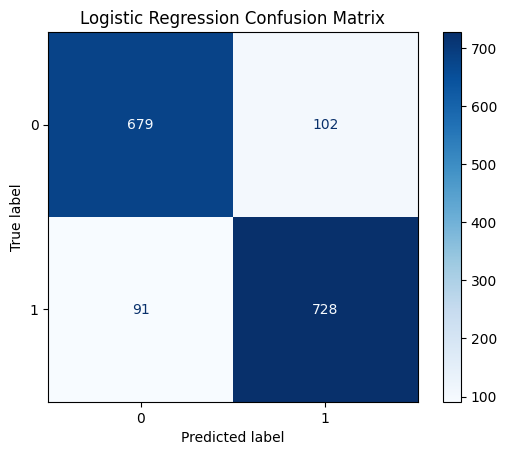

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Display colored confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, cmap="Blues")

plt.title("Logistic Regression Confusion Matrix")
plt.show()

AUC_ROC Curve

In [ ]:
#importing the tools
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

ROC Curve for Logistic Regression

⚠️ IMPORTANT: ROC needs probabilities, NOT predicted labels.

ROC = Receiver Operating Characteristic

👉 It is a graph showing how well a model separates two classes
(example: Good banana vs Bad banana)

It shows the trade-off between:

✅ True Positive Rate (TPR) → correctly detecting positives

Suppose your model predicts:

“This banana is GOOD with probability 0.8”

Now you must choose a threshold:

if probability > threshold → Good
else → Bad

If threshold = 0.5

Most bananas predicted Good.

✔ many correct

If threshold = 0.9

Model becomes strict.

👉 ROC curve shows performance for ALL thresholds at once.

That’s the key idea.

📊 What is plotted on the graph?

* X-axis → False Positive Rate (FPR)

--> How many bad bananas wrongly called good

* Y-axis → True Positive Rate (TPR)

--> How many good bananas correctly detected

Bad model

Curve follows diagonal:

same as random guessing

Good model

Curve bends upward:

detects positives well

AUC = Area Under Curve

It summarizes ROC into ONE number.

AUC	Meaning

0.5	random guessing

0.6	poor

0.7	acceptable

0.8	good

0.9	excellent

1.0	perfect

***ROC curve plots True Positive Rate vs False Positive Rate at different classification thresholds to measure model performance.***

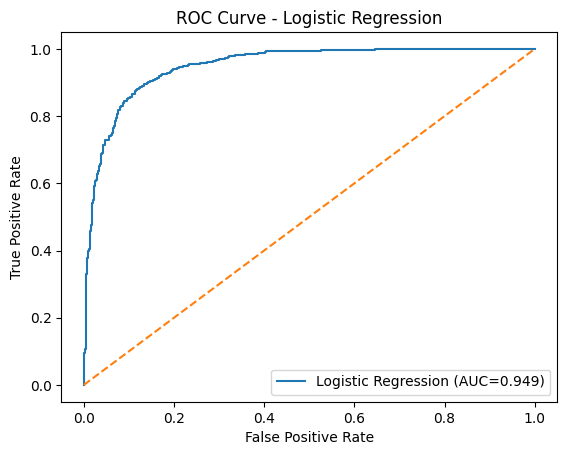

In [ ]:
# Get probability for class 1 (Good banana)
y_prob_lr = lr.predict_proba(X_test_scaled)[:,1]

# Compute ROC curve values
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)

# Compute AUC score
auc_lr = roc_auc_score(y_test, y_prob_lr)

# Plot ROC curve
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})")

# Diagonal reference line (random guessing)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

What if we cross validate

In [ ]:
# ML tools for cross validation
from sklearn.model_selection import cross_val_score, KFold


👉 data divided into 10 parts
👉 train on 9, test on 1
👉 repeat 10 times

In [ ]:
# Create a 10-fold splitter

kf = KFold(
    n_splits=10,   # ⭐ 10 folds
    shuffle=True,  # shuffle data before splitting
    random_state=42
)

Run cross-validation

In [ ]:
scores = cross_val_score(

    lr,
    X_train_scaled,
    y_train,

    cv=kf,              # use our 10-fold object
    scoring="accuracy"

)

print("Scores for each fold:\n", scores)
print("\nAverage accuracy:", scores.mean())

Scores for each fold:
 [0.865625  0.8890625 0.86875   0.88125   0.8734375 0.8796875 0.88125
 0.884375  0.8484375 0.890625 ]

Average accuracy: 0.87625


In [ ]:
lr.fit(X_train_scaled, y_train)

LogisticRegression()

In [ ]:
pred = lr.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Test Accuracy: 0.879375
              precision    recall  f1-score   support

           0       0.88      0.87      0.88       781
           1       0.88      0.89      0.88       819

    accuracy                           0.88      1600
   macro avg       0.88      0.88      0.88      1600
weighted avg       0.88      0.88      0.88      1600



Classification report for each fold

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [ ]:
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

Run manual CV loop and print report for each fold

In [ ]:
fold = 1
accuracies = []

for train_index, val_index in skf.split(X_train, y_train):

    print(f"\n========== FOLD {fold} ==========")

    # split training and validation data for this fold
    X_tr = X_train.iloc[train_index]
    X_val = X_train.iloc[val_index]

    y_tr = y_train.iloc[train_index]
    y_val = y_train.iloc[val_index]

    # IMPORTANT: scale INSIDE each fold (correct ML practice)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)

    # predict validation set
    pred = model.predict(X_val)

    # print classification report for this fold
    print(classification_report(y_val, pred))

    # store accuracy
    acc = accuracy_score(y_val, pred)
    accuracies.append(acc)

    fold += 1


========== FOLD 1 ==========
              precision    recall  f1-score   support

           0       0.88      0.88      0.88       321
           1       0.88      0.88      0.88       319

    accuracy                           0.88       640
   macro avg       0.88      0.88      0.88       640
weighted avg       0.88      0.88      0.88       640


========== FOLD 2 ==========
              precision    recall  f1-score   support

           0       0.88      0.86      0.87       321
           1       0.86      0.88      0.87       319

    accuracy                           0.87       640
   macro avg       0.87      0.87      0.87       640
weighted avg       0.87      0.87      0.87       640


========== FOLD 3 ==========
              precision    recall  f1-score   support

           0       0.89      0.88      0.89       321
           1       0.88      0.89      0.89       319

    accuracy                           0.89       640
   macro avg       0.89      0.89     

In [ ]:
acc_list = []
prec_list = []
rec_list = []
f1_list = []

for train_idx, val_idx in skf.split(X_train, y_train):

    # split data for this fold
    X_tr = X_train.iloc[train_idx]
    X_val = X_train.iloc[val_idx]
    y_tr = y_train.iloc[train_idx]
    y_val = y_train.iloc[val_idx]

    # scale inside fold (correct practice)
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_tr)
    X_val = scaler.transform(X_val)

    # train model
    model = LogisticRegression(max_iter=1000)
    model.fit(X_tr, y_tr)

    # predict
    pred = model.predict(X_val)

    # store metrics
    acc_list.append(accuracy_score(y_val, pred))
    prec_list.append(precision_score(y_val, pred))
    rec_list.append(recall_score(y_val, pred))
    f1_list.append(f1_score(y_val, pred))

In [ ]:
print("Average Accuracy :", np.mean(acc_list))
print("Average Precision:", np.mean(prec_list))
print("Average Recall   :", np.mean(rec_list))
print("Average F1-score :", np.mean(f1_list))

Average Accuracy : 0.8778125000000001
Average Precision: 0.8732461841028171
Average Recall   : 0.8835925947832258
Average F1-score : 0.8781707765292751


NEURAL NETWORK Classifier

importing model

In [ ]:

# Neural network classifier
from sklearn.neural_network import MLPClassifier

Fitting the model with the data

In [ ]:
# Simple neural network with 1 hidden layer

nn = MLPClassifier(
    hidden_layer_sizes=(20,),   # 20 neurons
    max_iter=500,
    random_state=42
)

nn.fit(X_train_scaled, y_train)

MLPClassifier(hidden_layer_sizes=(20,), max_iter=500, random_state=42)

Results and evaluation

In [ ]:
y_pred_nn = nn.predict(X_test_scaled)

print("Accuracy:", accuracy_score(y_test, y_pred_nn))

print(classification_report(y_test, y_pred_nn))

Accuracy: 0.9825
              precision    recall  f1-score   support

           0       0.99      0.98      0.98       781
           1       0.98      0.99      0.98       819

    accuracy                           0.98      1600
   macro avg       0.98      0.98      0.98      1600
weighted avg       0.98      0.98      0.98      1600



ROC Curve

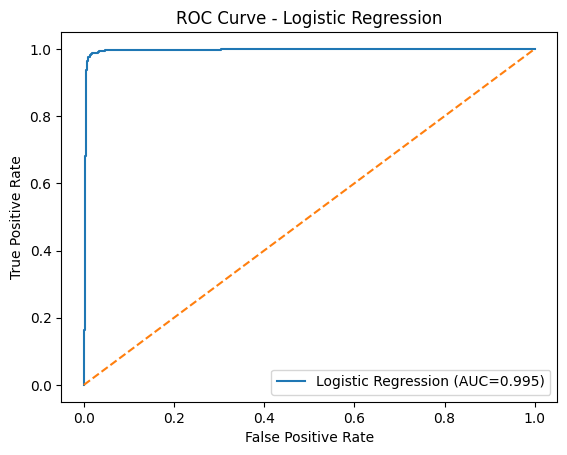

In [ ]:
# Get probability for class 1 (Good banana)
y_prob_nn = nn.predict_proba(X_test_scaled)[:,1]

# Compute ROC curve values
fpr_nn, tpr_nn, _ = roc_curve(y_test, y_prob_nn)

# Compute AUC score
auc_nn = roc_auc_score(y_test, y_prob_nn)

# Plot ROC curve
plt.plot(fpr_nn, tpr_nn, label=f"Logistic Regression (AUC={auc_nn:.3f})")

# Diagonal reference line (random guessing)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")

plt.legend()
plt.show()

Confusion matrix

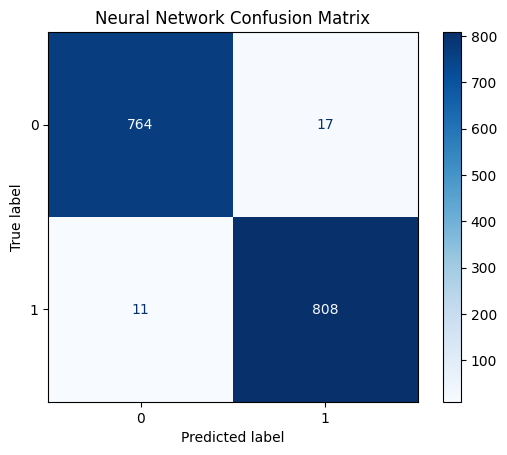

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Display colored confusion matrix
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_nn, cmap="Blues")

plt.title("Neural Network Confusion Matrix")
plt.show()